In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn #nn contains all of pytorch's building blocks for neural networks
print(torch.__version__)
from torch import nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

2.5.1+cu121


Computer Vision

1.Getting a dataset

In [14]:
#setup training data
from torchvision import datasets
train_data=datasets.FashionMNIST(
    root="data",#where to download data to
    train=True,#do we want the training data?
    download=True,#do we want to download?
    transform=torchvision.transforms.ToTensor(),#how do we want to transform the data
    target_transform=None#how do we want transform the labels
)

test_data=datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

In [15]:
len(train_data),len(test_data)

(60000, 10000)

In [16]:
class_names=train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [17]:
class_to_idx=train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [18]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [19]:
image,label=train_data[0]
image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [20]:
#check the shape of our image
print(f"image shape:{image.shape}")#->[colour_channel,height,width]
print(f"image label:{class_names[label]}")

image shape:torch.Size([1, 28, 28])
image label:Ankle boot


image shape:torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

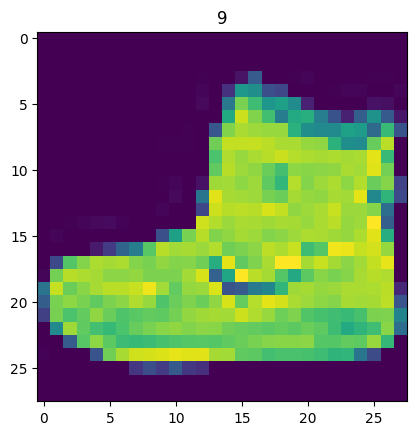

In [23]:
#1.2 Visualizing the data
image,label=train_data[0]
print(f"image shape:{image.shape}")

plt.imshow(image.squeeze())
plt.title(label)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

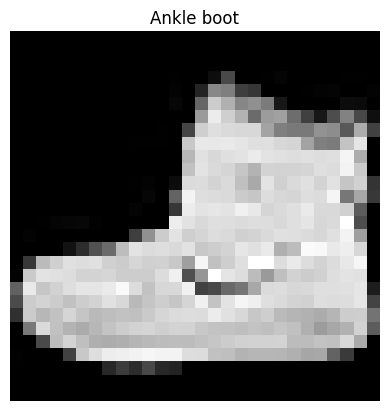

In [26]:
plt.imshow(image.squeeze(),cmap="gray")
plt.title(class_names[label])
plt.axis(False)

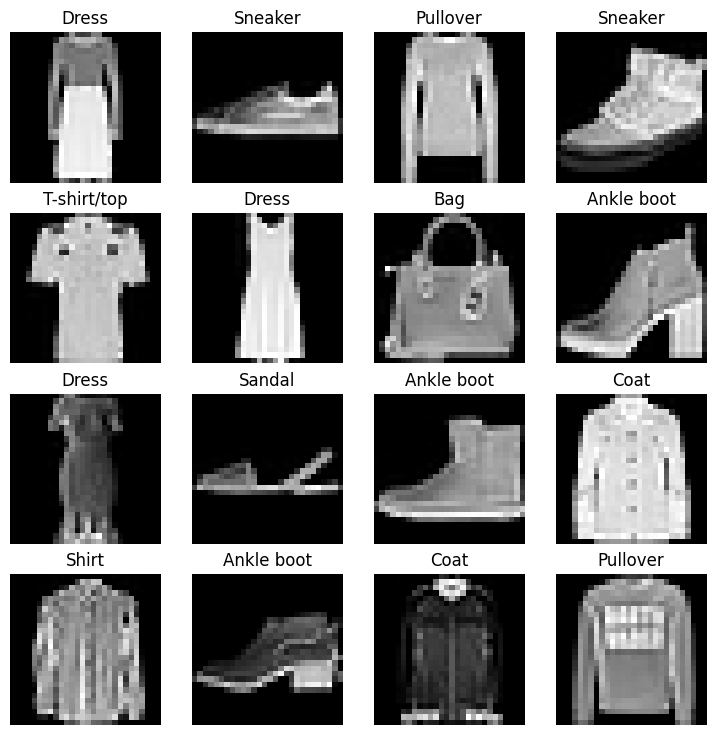

In [37]:
#plot more images 
# torch.manual_seed(42)
fig=plt.figure(figsize=(9,9))
row,col=4,4

for i in range(1,row*col+1):
    random_idx=torch.randint(0,len(train_data),size=[1]).item()
    img,lbl=train_data[random_idx]
    fig.add_subplot(row,col,i)
    plt.imshow(img.squeeze(),cmap="gray")
    plt.title(class_names[lbl])
    plt.axis(False)

2.Prepare dataloader

dataloader turns out data into a python iterable

we want to turn our data into mini batches

why would you do this?
1.it is more computationally efficient,as in your computing hardware may not be
able to look at 60000 images in one hit.so we break it down to 32 images at a time
2.it gives our neural network more changes to update its gradient per epoch.


In [38]:
from torch.utils.data import DataLoader

#setup the batch size hyperparameter
BATCH_SIZE=32

train_dataloader=DataLoader(dataset=train_data,
                            batch_size=BATCH_SIZE,
                            shuffle=True)

test_dataloader=DataLoader(dataset=test_data,
                           batch_size=BATCH_SIZE,
                           shuffle=False)

train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x1b5664b6270>,
 <torch.utils.data.dataloader.DataLoader at 0x1b5664d8a40>)

In [39]:
print(f"dataloader:{train_dataloader,test_dataloader}")

dataloader:(<torch.utils.data.dataloader.DataLoader object at 0x000001B5664B6270>, <torch.utils.data.dataloader.DataLoader object at 0x000001B5664D8A40>)


In [40]:
#check out what's inside the training dataloader
train_features_batch,train_label_batch=next(iter(train_dataloader))
train_features_batch.shape,train_label_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

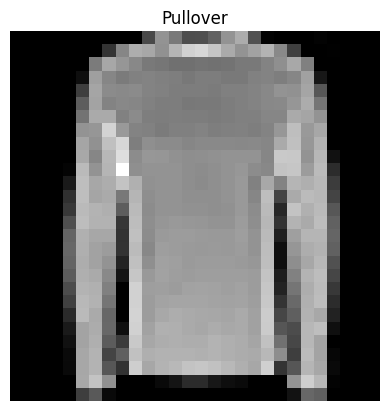

In [42]:
#show a sample
torch.manual_seed(42)
random_idx=torch.randint(0,len(train_features_batch),size=[1]).item()
img,lbl=train_features_batch[random_idx],train_label_batch[random_idx]
plt.imshow(img.squeeze(),cmap="gray")
plt.title(class_names[lbl])
plt.axis(False)
